In [369]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder,StandardScaler 
from sklearn.ensemble import ExtraTreesRegressor,GradientBoostingRegressor,RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [527]:
df = pd.read_csv("C:/Users/user/Downloads/train.csv")

In [529]:
df_test = pd.read_csv("C:/Users/user/Downloads/test.csv") 

In [531]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   object 
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          107 non-null    object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int64  
 18  OverallC

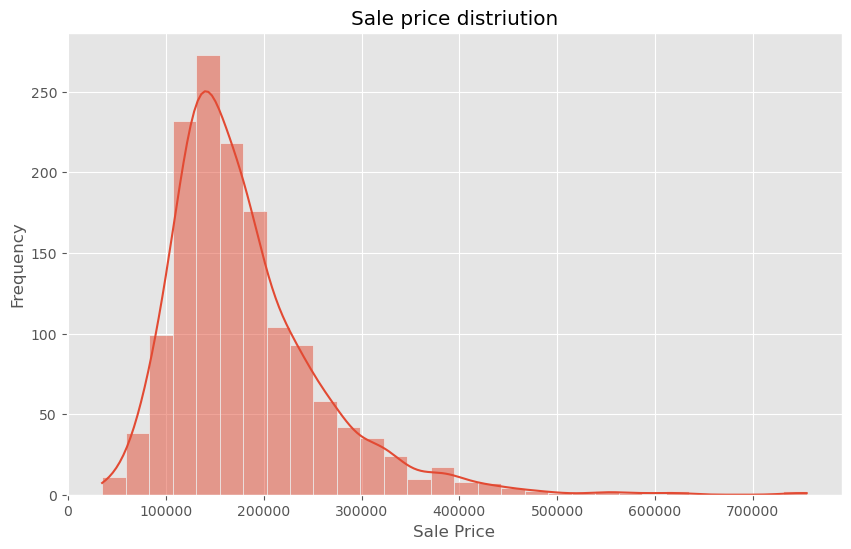

In [533]:
plt.style.use("ggplot")
plt.figure(figsize = (10,6))
sns.histplot(df.SalePrice,bins=30,kde=True)
plt.xlabel("Sale Price")
plt.ylabel("Frequency")
plt.title("Sale price distriution")
plt.show()

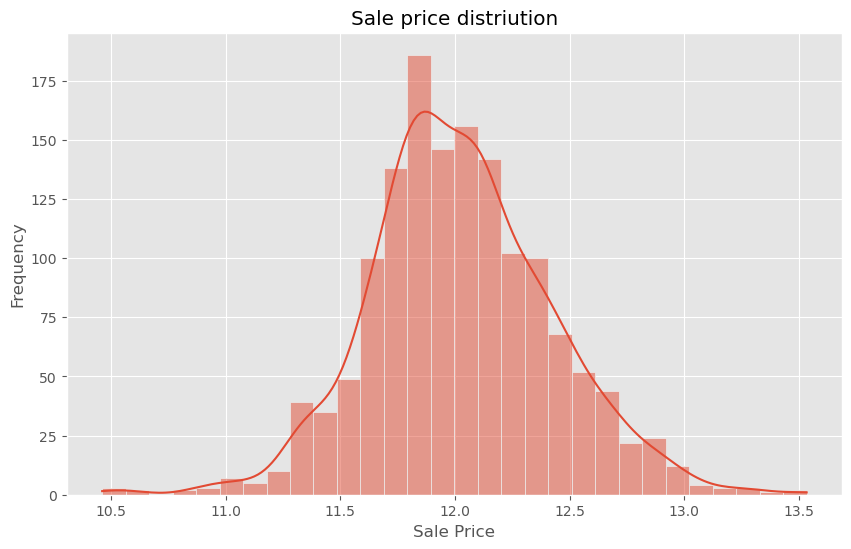

In [535]:
df.SalePrice = np.log(df.SalePrice)
plt.figure(figsize=(10,6))
sns.histplot(df.SalePrice,bins= 30,kde=True)
plt.xlabel("Sale Price")
plt.ylabel("Frequency")
plt.title("Sale price distriution")
plt.show()

In [537]:
numerical_features = df.select_dtypes(include = ["number"])
correlated_features = numerical_features.corr()
top_correlated_features = correlated_features.SalePrice.sort_values(ascending=False).head(10)

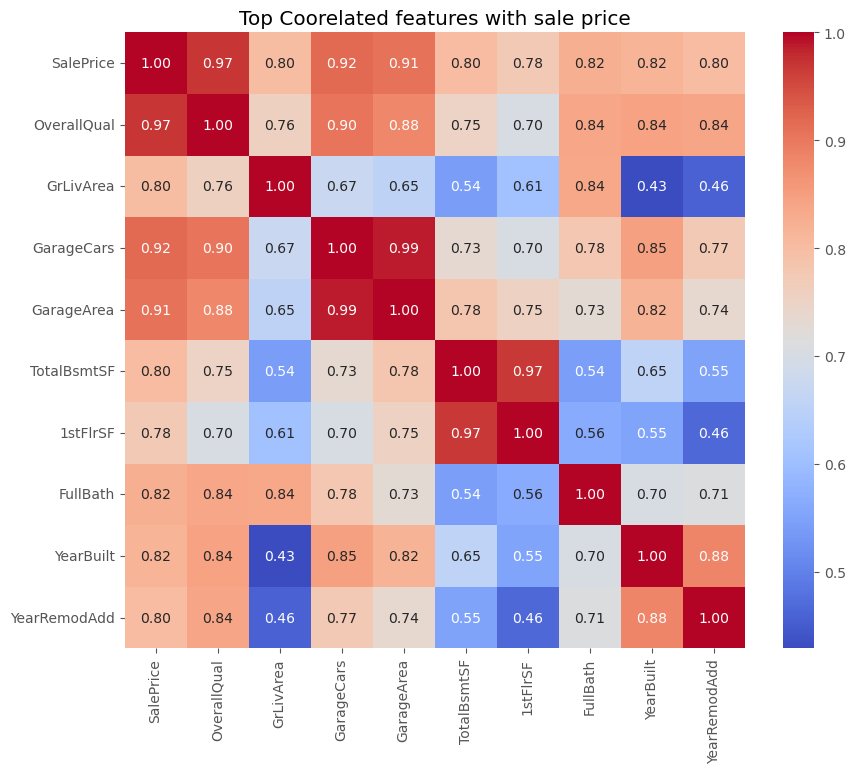

In [539]:
plt.figure(figsize = (10,8))
sns.heatmap(correlated_features[top_correlated_features.index].corr(),annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Top Coorelated features with sale price")
plt.show()

In [540]:
missing_values = df.isnull().sum().sort_values(ascending =False)
missing_values =  missing_values[missing_values>0]
missing_values.shape

(19,)

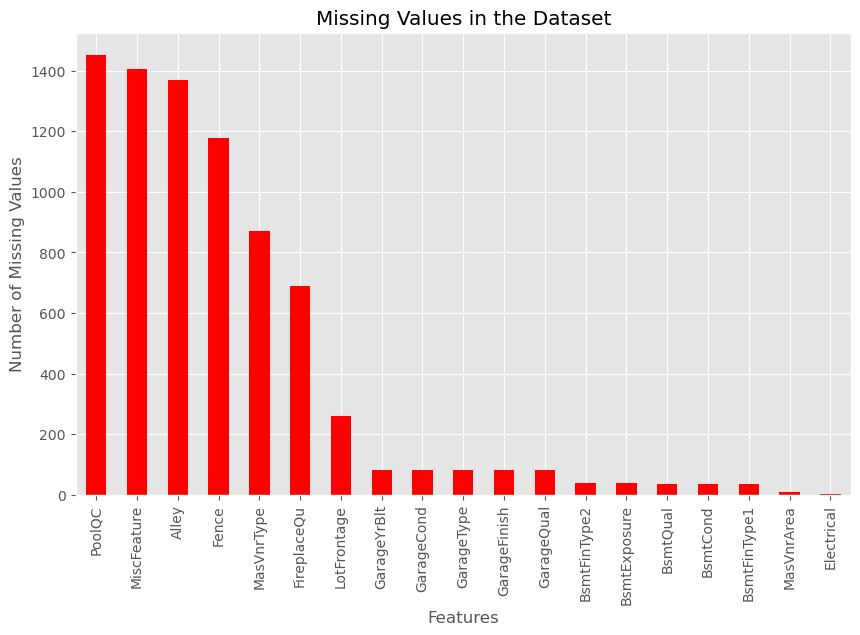

In [543]:
plt.figure(figsize = (10,6))
missing_values.plot(kind="bar",color="red")
plt.xlabel("Features")
plt.ylabel("Number of Missing Values")
plt.title("Missing Values in the Dataset")
plt.xticks(rotation=90)
plt.show()


In [544]:
df_test.shape

(1459, 80)

In [547]:
df.drop('PoolQC',axis =1,inplace= True)
df.drop('MiscFeature',axis =1,inplace= True)
df.drop('Alley',axis =1,inplace= True)
df.drop('Fence',axis =1,inplace= True)
df.drop('FireplaceQu',axis =1,inplace= True)
Id = df["Id"]
df.drop("Id",axis=1,inplace=True)

In [549]:
df_test.shape

(1459, 80)

In [551]:
df_test.drop('PoolQC',axis =1,inplace= True)
df_test.drop('MiscFeature',axis =1,inplace= True)
df_test.drop('Alley',axis =1,inplace= True)
df_test.drop('Fence',axis =1,inplace= True)
df_test.drop('FireplaceQu',axis =1,inplace= True)

df_test.drop("Id",axis=1,inplace=True)

In [553]:
df_test.shape

(1459, 74)

In [555]:
df.MasVnrType=df.MasVnrType.fillna("None")
df.BsmtQual = df.BsmtQual.fillna("None")
df.BsmtCond = df.BsmtCond.fillna("None")
df.BsmtFinType1 = df.BsmtFinType1.fillna("None")
df.BsmtFinType2= df.BsmtFinType2.fillna("None")
df.BsmtExposure = df.BsmtExposure.fillna("None")
df.GarageQual= df.GarageQual.fillna("None")
df.GarageCond = df.GarageCond.fillna("None")
df.GarageType = df.GarageType.fillna("None")
df.GarageFinish = df.GarageFinish.fillna("None")
df.Electrical = df.Electrical.fillna("None")

In [557]:
missing_values_test = df_test.isnull().sum()  
missing_values_test = missing_values_test[missing_values_test>0]
missing_values_test

MSZoning          4
LotFrontage     227
Utilities         2
Exterior1st       1
Exterior2nd       1
MasVnrType      894
MasVnrArea       15
BsmtQual         44
BsmtCond         45
BsmtExposure     44
BsmtFinType1     42
BsmtFinSF1        1
BsmtFinType2     42
BsmtFinSF2        1
BsmtUnfSF         1
TotalBsmtSF       1
BsmtFullBath      2
BsmtHalfBath      2
KitchenQual       1
Functional        2
GarageType       76
GarageYrBlt      78
GarageFinish     78
GarageCars        1
GarageArea        1
GarageQual       78
GarageCond       78
SaleType          1
dtype: int64

In [559]:
df_test.shape

(1459, 74)

In [561]:
df_test.MasVnrType=df_test.MasVnrType.fillna("None")
df_test.BsmtQual = df_test.BsmtQual.fillna("None")
df_test.BsmtCond = df_test.BsmtCond.fillna("None")
df_test.BsmtFinType1 = df_test.BsmtFinType1.fillna("None")
df_test.BsmtFinType2= df_test.BsmtFinType2.fillna("None")
df_test.BsmtExposure = df_test.BsmtExposure.fillna("None")
df_test.GarageQual= df_test.GarageQual.fillna("None")
df_test.GarageCond = df_test.GarageCond.fillna("None")
df_test.GarageType = df_test.GarageType.fillna("None")
df_test.GarageFinish = df_test.GarageFinish.fillna("None")

In [563]:
df_test.shape

(1459, 74)

In [565]:
df.LotFrontage= df.LotFrontage.fillna(df.LotFrontage.median())
df.MasVnrArea = df.MasVnrArea.fillna(df.MasVnrArea.median())
df.GarageYrBlt = df.GarageYrBlt.fillna(df.GarageYrBlt.median())

In [567]:
df_test.shape

(1459, 74)

In [569]:
df_test.BsmtFinSF1 = df_test.BsmtFinSF1.fillna(df_test.BsmtFinSF1.median())
df_test.BsmtFinSF2 = df_test.BsmtFinSF2.fillna(df_test.BsmtFinSF2.median())
df_test.BsmtUnfSF = df_test.BsmtUnfSF .fillna(df_test.BsmtUnfSF.median())
df_test.TotalBsmtSF= df_test.TotalBsmtSF.fillna(df_test.TotalBsmtSF.median())
df_test.BsmtFullBath = df_test.BsmtFullBath.fillna(df_test.BsmtFullBath.median())
df_test.BsmtHalfBath = df_test.BsmtHalfBath.fillna(df_test.BsmtHalfBath.median())
df_test.GarageCars= df_test.GarageCars.fillna(df_test.GarageCars.median())
df_test.GarageArea = df_test.GarageArea.fillna(df_test.GarageArea.median())

In [571]:
df_test.shape

(1459, 74)

In [573]:
df_test.LotFrontage= df_test.LotFrontage.fillna(df_test.LotFrontage.median())
df_test.MasVnrArea = df_test.MasVnrArea.fillna(df_test.MasVnrArea.median())
df_test.GarageYrBlt = df_test.GarageYrBlt.fillna(df_test.GarageYrBlt.median())

In [517]:
df_test.shape

(1459, 74)

In [575]:
df_test.Utilities= df_test.Utilities.fillna(df_test.Utilities.mode()[0])
df_test.Exterior1st = df_test.Exterior1st.fillna(df_test.Exterior1st.mode()[0])
df_test.Exterior2nd= df_test.Exterior2nd.fillna(df_test.Exterior2nd.mode()[0])
df_test.KitchenQual = df_test.KitchenQual.fillna(df_test.KitchenQual.mode()[0])
df_test.Functional = df_test.Functional.fillna(df_test.Functional.mode()[0])
df_test.SaleType = df_test.SaleType.fillna(df_test.SaleType.mode()[0])
df_test.MSZoning = df_test.MSZoning.fillna(df_test.MSZoning.mode()[0])

In [583]:
df_test.shape

(1459, 74)

In [589]:
category_Cols = df.select_dtypes(include=["object"]).columns
encoder = OneHotEncoder(handle_unknown="ignore",sparse_output=False,drop="first")
encoded_df = pd.DataFrame(encoder.fit_transform(df[category_Cols]))
encoded_df_test = pd.DataFrame(encoder.transform(df[category_Cols]))
encoded_df.columns = encoder.get_feature_names_out(category_Cols)
encoded_df_test.columns = encoder.get_feature_names_out(category_Cols)
encoded_df_test.index = df.
df = pd.concat([df,encoded_df], axis=1)
df_test = pd.concat([df_test,encoded_df_test],axis=1)

ValueError: Shape of passed values is (1460, 206), indices imply (1459, 206)

In [587]:
df_test.shape

(1459, 280)

In [389]:
df.drop(category_Cols,axis=1,inplace=True)

In [390]:
df_test.drop(category_Cols,axis=1,inplace=True)

In [391]:
numeric_columns =  [col for col in df.columns if col != "SalePrice"]
scaler = StandardScaler()
df[numeric_columns] = scaler.fit_transform(df[numeric_columns])
df_test[numeric_columns] = scaler.transform(df_test[numeric_columns])

In [392]:
x = df.drop(columns=["SalePrice"])
y = df.SalePrice

In [393]:
model = ExtraTreesRegressor(n_estimators=100,random_state=42)
model.fit(x,y)

ExtraTreesRegressor(random_state=42)

In [394]:
feature_importance = model.feature_importances_

In [395]:
feature_importance_df = pd.DataFrame({"Feature":x.columns,"Importance":feature_importance})
feature_importance_df = feature_importance_df.sort_values(by="Importance",ascending=False)

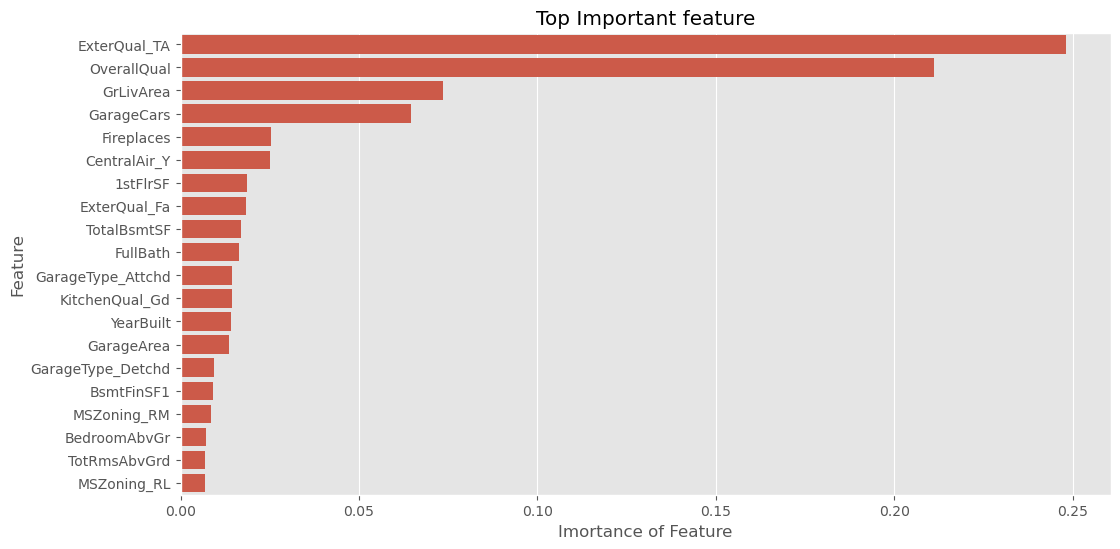

In [396]:
top_features = feature_importance_df.head(20)
plt.figure(figsize=(12,6))
sns.barplot(x=top_features["Importance"],y=top_features["Feature"])
plt.xlabel("Imortance of Feature")
plt.ylabel("Feature")
plt.title("Top Important feature")
plt.show()

In [397]:
selected_feature = top_features["Feature"].tolist()
x_selected = df[selected_feature]

In [398]:
models_optimized = {
    "RandomForest": RandomForestRegressor(n_estimators=100,random_state=42),
    "LinearRegression": LinearRegression(),
    "GradienBoosting": GradientBoostingRegressor(n_estimators=100,random_state=42),
    "XGBoost" : XGBRegressor(n_estimators=100,random_state=42,objective="reg:squarederror")
} 

In [399]:
model_performance_results = []

for model_name , models in models_optimized.items():
    models.fit(x,y)
    y_pred = models.predict(x)
    mae = mean_absolute_error(y,y_pred)
    mse = mean_squared_error(y,y_pred)
    rmse = mse**0.5
    r2 = r2_score(y,y_pred)

    model_performance_results.append({
        "Model":model_name,
        "Mean_absolute_error":mae,
        "Mean_squared_error" :mse,
        "Root_mean_sqaured_error":rmse,
        "r2": r2
    })

In [400]:
model_performance_df = pd.DataFrame( model_performance_results)
model_performance_df

,Model,Mean_absolute_error,Mean_squared_error,Root_mean_sqaured_error,r2
0,RandomForest,0.035708,0.002920,0.054041,0.981685
1,LinearRegression,0.066149,0.009095,0.095369,0.942959
2,GradienBoosting,0.061523,0.007050,0.083965,0.955785
3,XGBoost,0.006961,0.000101,0.010055,0.999366


In [457]:
df_test.shape

(1460, 242)

In [451]:

model =  XGBRegressor(n_estimators=100,random_state=42,objective="reg:squarederror")
model.fit(x,y)
y_pred = model.predict(df_test)
y_pred = np.expm1(y_pred)
y_pred.size

1460

In [447]:
submission = pd.DataFrame({
    "Id":Id,
    "SalePrice":y_pred})

In [449]:
submission

,Id,SalePrice
0,1,137992.500000
1,2,161833.187500
2,3,197102.156250
3,4,183528.828125
4,5,185254.609375
...,...,...
1455,1456,80631.804688
1456,1457,178177.453125
1457,1458,126284.890625
1458,1459,236020.093750
